# 05 · Renewable Generator Analysis

Analyses the `RenewableGen` module: 100 MW IEC wind farm and 75 MW solar PV plant.

In [1]:
import sys, os
os.chdir("/lustre/guillant/C2G-Macro")
sys.path.insert(0, ".")
import numpy as np, matplotlib.pyplot as plt
from c2g_env.simulators.renewable import RenewableGen

rg = RenewableGen(renewable_dir="data/processed/renewable",
                  wind_capacity_mw=100, solar_capacity_mw=75)
# Iterate through all ticks
N = 8640   # 30 days
wind_p, solar_p, total_p = [], [], []
for tick in range(N):
    out = rg.get_generation(tick)
    wind_p.append(out["p_wind_mw"]); solar_p.append(out["p_solar_mw"])
    total_p.append(out["p_renewable_mw"])
wind_p = np.array(wind_p); solar_p = np.array(solar_p); total_p = np.array(total_p)
cf_wind  = wind_p.mean()  / 100
cf_solar = solar_p.mean() / 75
print(f"Wind CF:  {cf_wind*100:.1f}%   Solar CF: {cf_solar*100:.1f}%")
print(f"Total range: {total_p.min():.1f} – {total_p.max():.1f} MW  mean={total_p.mean():.1f} MW")

Wind CF:  68.5%   Solar CF: 4.2%
Total range: 0.0 – 124.4 MW  mean=71.6 MW


## 5.1 Time Series — Wind + Solar

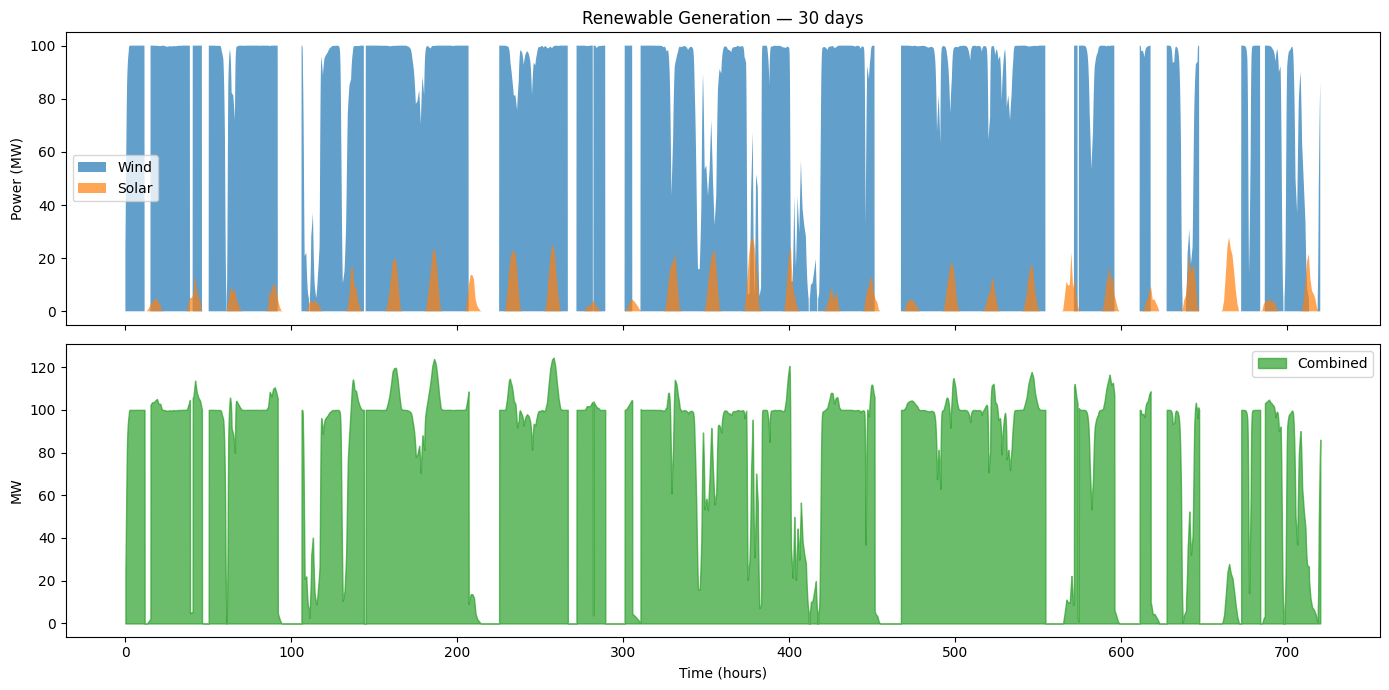

In [2]:
t = np.arange(N) * 5 / 60  # hours
fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)
axes[0].fill_between(t, wind_p,  alpha=0.7, label="Wind"); axes[0].fill_between(t, solar_p, alpha=0.7, label="Solar")
axes[0].set_ylabel("Power (MW)"); axes[0].legend(); axes[0].set_title("Renewable Generation — 30 days")
axes[1].fill_between(t, total_p, alpha=0.7, color="tab:green", label="Combined")
axes[1].set_ylabel("MW"); axes[1].set_xlabel("Time (hours)"); axes[1].legend()
plt.tight_layout(); plt.savefig("notebooks/fig_ren_timeseries.png", dpi=120); plt.show()

## 5.2 IEC Wind Power Curve

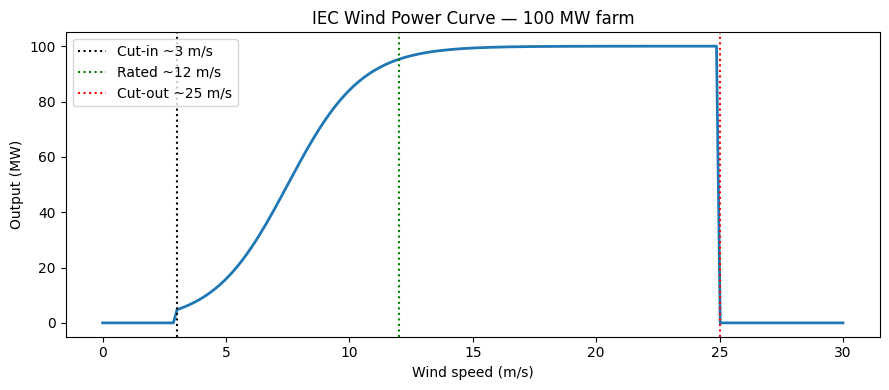

In [3]:
speeds = np.linspace(0, 30, 200)
wind_curve = np.array([rg.wind_power(v) for v in speeds])

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(speeds, wind_curve, lw=2, color="tab:blue")
ax.axvline(3,  color="k", ls=":", label="Cut-in ~3 m/s")
ax.axvline(12, color="g", ls=":", label="Rated ~12 m/s")
ax.axvline(25, color="r", ls=":", label="Cut-out ~25 m/s")
ax.set_xlabel("Wind speed (m/s)"); ax.set_ylabel("Output (MW)")
ax.set_title("IEC Wind Power Curve — 100 MW farm"); ax.legend()
plt.tight_layout(); plt.savefig("notebooks/fig_ren_wind_curve.png", dpi=120); plt.show()

## 5.3 Diurnal Solar Profile

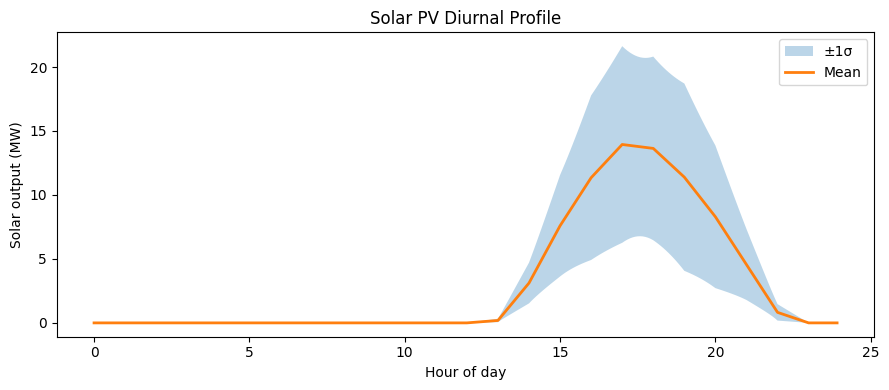

In [4]:
# Tick mod 288 = time-of-day
tod = np.arange(N) % 288
solar_tod_mean = [solar_p[tod == h].mean() for h in range(288)]
solar_tod_std  = [solar_p[tod == h].std()  for h in range(288)]
t_day = np.arange(288) * 5 / 60

fig, ax = plt.subplots(figsize=(9, 4))
ax.fill_between(t_day, np.array(solar_tod_mean)-np.array(solar_tod_std),
                        np.array(solar_tod_mean)+np.array(solar_tod_std), alpha=0.3, label="±1σ")
ax.plot(t_day, solar_tod_mean, lw=2, color="tab:orange", label="Mean")
ax.set_xlabel("Hour of day"); ax.set_ylabel("Solar output (MW)")
ax.set_title("Solar PV Diurnal Profile"); ax.legend()
plt.tight_layout(); plt.savefig("notebooks/fig_ren_solar_diurnal.png", dpi=120); plt.show()

## 5.4 Combined Capacity Factor Histogram

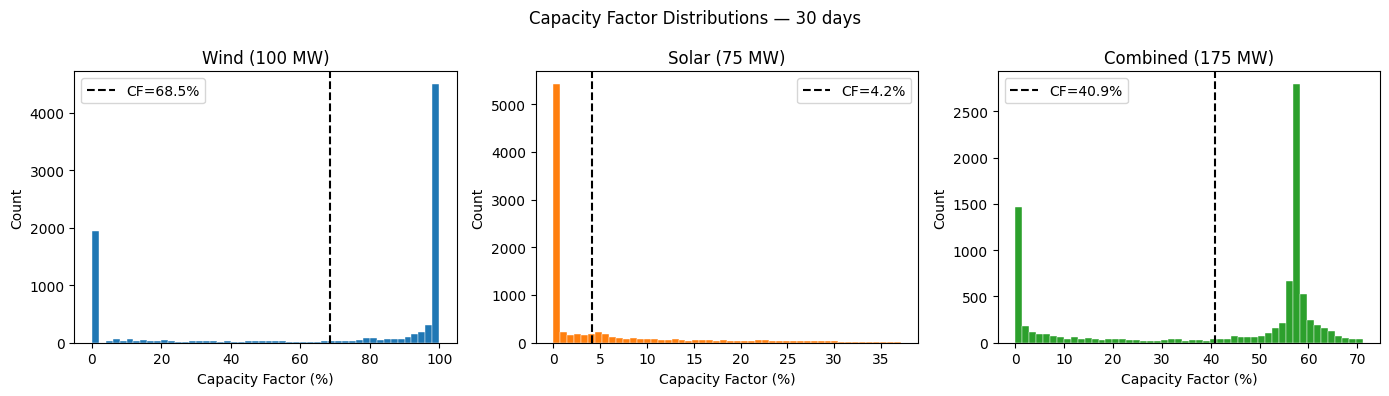

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, data, cap, name, color in zip(
        axes, [wind_p, solar_p, total_p], [100, 75, 175],
        ["Wind (100 MW)", "Solar (75 MW)", "Combined (175 MW)"],
        ["tab:blue", "tab:orange", "tab:green"]):
    cf = data / cap
    ax.hist(cf*100, bins=50, color=color, edgecolor="white", lw=0.3)
    ax.axvline(cf.mean()*100, color="k", ls="--", label=f"CF={cf.mean()*100:.1f}%")
    ax.set_xlabel("Capacity Factor (%)"); ax.set_ylabel("Count"); ax.set_title(name); ax.legend()
plt.suptitle("Capacity Factor Distributions — 30 days"); plt.tight_layout()
plt.savefig("notebooks/fig_ren_cf.png", dpi=120); plt.show()